# Rent Data Cleaning and EDA

This notebook cleans raw rental listings scraped from Madlan.

The goal is to create a clean dataset with these final columns:

- City
- Neighborhood
- price
- rooms
- price_per_room
- price_per_sqm

This cleaned dataset will later be used to compare rent prices across different cities in Israel.

In [300]:
# Import libraries for data cleaning, analysis and visualization
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt

## 1. Project Settings

Here I define the city name and the output file name.

To reuse this notebook for another city, I only need to change these two variables.

In [301]:
# Define the city name
CITY_NAME = "Ramat Gan"

# Define the output file name
OUTPUT_FILE = "ramat_gan_rent_clean.csv"

# Test that the variables are working
print("City selected:", CITY_NAME)
print("Output file:", OUTPUT_FILE)

City selected: Ramat Gan
Output file: ramat_gan_rent_clean.csv


## 2. Load Raw CSV Files

I uploaded several CSV files scraped from Madlan using a Chrome extension.

In this step, I combine all raw CSV files into one dataframe.

In [302]:
# Find all CSV files uploaded to Colab
csv_files = glob.glob("*.csv")

# Display the list of files
csv_files

['RG_rent3.csv',
 'RG_rent8.csv',
 'RG_rent5.csv',
 'RG_rent4.csv',
 'RG_rent2.csv',
 'RG_rent9.csv',
 'ramat_gan_rent_clean.csv',
 'RG_rent6.csv',
 'RG_rent7.csv',
 'RG_rent1.csv']

In [303]:
# Create an empty list to store each CSV dataframe
raw_list = []

# Loop through every CSV file and read it
for file in csv_files:
    df = pd.read_csv(file)

    # Add the original file name for tracking
    df["original_file"] = file

    raw_list.append(df)

# Combine all CSV files into one dataframe
raw_rent = pd.concat(raw_list, ignore_index=True)

# Check the shape of the combined dataframe
raw_rent.shape

(477, 17)

In [304]:
# Preview the first rows of the raw scraped data
raw_rent.head()

,css-u1nut8 href,css-17p3j9b src,css-hqth87,css-q8j3hw,css-q8j3hw 2,css-q8j3hw 3,css-n4p85g,css-afgd57,original_file,thumbnail-logo href,thumbnail-logo src,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,https://www.madlan.co.il/listings/RxCDOolDrU4,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"‏7,500 ‏₪",4 חד׳,קומה 2,"106 מ""ר","דירה, הבילויים 40, הבילויים",NaN,RG_rent3.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.madlan.co.il/listings/inAnoxJSjwE,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"‏4,800 ‏₪",3 חד׳,קומת קרקע,"60 מ""ר","דירה, שרה אהרונסון 45, הבילויים",NaN,RG_rent3.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.madlan.co.il/listings/dXuZ1pMtvGd,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"‏5,800 ‏₪",3 חד׳,קומה 2,"80 מ""ר","דירה, שרה אהרונסון , הבילויים",תיווך,RG_rent3.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.madlan.co.il/listings/HKoWXrUSiOO,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"‏5,400 ‏₪",3 חד׳,קומה 3,"85 מ""ר","דירה, שדרות הקונגרס , הבילויים",תיווך,RG_rent3.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.madlan.co.il/listings/gW1t3Ruquc6,https://images2.madlan.co.il/t:nonce:v=2;resiz...,"‏10,000 ‏₪",4 חד׳,קומה 8,"92 מ""ר","דירה, עלומים 12, הבילויים",NaN,RG_rent3.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [305]:
# Display all column names
raw_rent.columns

Index(['css-u1nut8 href', 'css-17p3j9b src', 'css-hqth87', 'css-q8j3hw',
       'css-q8j3hw 2', 'css-q8j3hw 3', 'css-n4p85g', 'css-afgd57',
       'original_file', 'thumbnail-logo href', 'thumbnail-logo src', 'City',
       'Neighborhood', 'price', 'rooms', 'price_per_room', 'price_per_sqm'],
      dtype='object')

## 3. Select and Rename Useful Columns

The scraped data contains messy column names.

In this step, I select the columns that contain the important rental information and create a cleaner dataframe.

In [306]:
# Create a clean dataframe
rent = pd.DataFrame()

# Add city name manually
rent["City"] = CITY_NAME

# Full raw location string
full_location = raw_rent["css-n4p85g"].astype(str)

# Extract address
rent["Address"] = (
    full_location
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract neighborhood
rent["Neighborhood"] = (
    full_location
    .str.split(",")
    .str[-1]
    .str.strip()
)

# Extract price
rent["price"] = raw_rent["css-hqth87"]

# Extract rooms
rent["rooms"] = raw_rent["css-q8j3hw"]

# Extract apartment size
rent["size_sqm"] = raw_rent["css-q8j3hw 3"]

# Preview dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הבילויים,"‏7,500 ‏₪",4 חד׳,"106 מ""ר"
1,NaN,דירה,הבילויים,"‏4,800 ‏₪",3 חד׳,"60 מ""ר"
2,NaN,דירה,הבילויים,"‏5,800 ‏₪",3 חד׳,"80 מ""ר"
3,NaN,דירה,הבילויים,"‏5,400 ‏₪",3 חד׳,"85 מ""ר"
4,NaN,דירה,הבילויים,"‏10,000 ‏₪",4 חד׳,"92 מ""ר"


## 4. Clean Numeric Columns

The price, rooms and size columns may contain text, symbols or extra characters.

In this step, I extract only the numeric values and convert them into numeric data types.

In [307]:
# Clean price column
rent["price"] = (
    rent["price"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Clean rooms column
rent["rooms"] = (
    rent["rooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Clean size_sqm column
rent["size_sqm"] = (
    rent["size_sqm"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Preview cleaned dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הבילויים,7500.0,4.0,106.0
1,NaN,דירה,הבילויים,4800.0,3.0,60.0
2,NaN,דירה,הבילויים,5800.0,3.0,80.0
3,NaN,דירה,הבילויים,5400.0,3.0,85.0
4,NaN,דירה,הבילויים,10000.0,4.0,92.0


## 5. Clean Neighborhood Column

The neighborhood column may contain extra text.

In this step, I clean the neighborhood names and keep them as readable text.

In [308]:
# Convert neighborhood column to string and clean extra spaces
rent["Neighborhood"] = (
    rent["Neighborhood"]
    .astype(str)
    .str.strip()
)

# Replace empty or invalid values with NaN
rent["Neighborhood"] = rent["Neighborhood"].replace(["nan", "", "None"], np.nan)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הבילויים,7500.0,4.0,106.0
1,NaN,דירה,הבילויים,4800.0,3.0,60.0
2,NaN,דירה,הבילויים,5800.0,3.0,80.0
3,NaN,דירה,הבילויים,5400.0,3.0,85.0
4,NaN,דירה,הבילויים,10000.0,4.0,92.0


In [309]:
# Translate neighborhood names to English

# Clean neighborhood column
rent["Neighborhood"] = rent["Neighborhood"].astype(str).str.strip()

# Dictionary with neighborhood translations
neighborhood_map = {

    # Main neighborhoods
    "הבורסה": "Bursa District",
    "נחלת גנים": "Nahalat Ganim",
    "יד לבנים": "Yad Labanim",
    "תל יהודה": "Tel Yehuda",
    "רמת יצחק": "Ramat Yitzhak",
    "רמת חן": "Ramat Hen",
    "רמת שקמה": "Ramat Shikma",

    # City center
    "מרכז רמת גן": "Central Ramat Gan",
    "מרכז העיר א'": "City Center A",
    "מרכז העיר ב'": "City Center B",
    "מרכז העיר ג'": "City Center C",

    # Additional neighborhoods
    "מרום נווה": "Merom Naveh",
    "חרוזים": "Haruzim",
    "החרוזים": "Haruzim",
    "תל בנימין": "Tel Binyamin",
    "קריניצי": "Krinitsi",
    "קרית קריניצי": "Kiryat Krinitzi",

    # HaGefen variations
    "הגפן": "HaGefen",
    "שכונת הגפן": "HaGefen",

    # Residential areas
    "רמת עמידר": "Ramat Amidar",
    "שיכון ותיקים": "Shikun Vatikim",
    "נווה יהושע": "Neve Yehoshua",
    "נווה יהושע ופארק לאומי": "Neve Yehoshua & National Park",
    "רמת יצחק ובן גוריון": "Ramat Yitzhak & Ben Gurion",

    # Smaller areas
    "שכונת הראשונים": "HaRishonim",
    "שנקר": "Shenkar",
    "תל גנים": "Tel Ganim",
    "גבעת גאולה": "Givat Geula",
    "עמידר": "Amidar",
    "שכונת הלל": "Hillel",
    "הבילויים": "HaBiluim",
    "החשמונאים (מרכז העיר א')": "HaHashmonaim",

    # Remaining untranslated neighborhoods
    "נווה רם": "Neve Ram",
    "מתחם נגבה": "Negba Complex",
    "פועלי הרכבת": "Poalei HaRakevet",
    "הר שלום": "Har Shalom"

}

# Replace Hebrew names with English names
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

# Preview translated neighborhoods
rent["Neighborhood"].unique()

array(['HaBiluim', 'Neve Yehoshua', 'Negba Complex', 'Tel Ganim',
       'Neve Ram', 'Tel Yehuda', 'Ramat Yitzhak', 'שיינקין',
       'Yad Labanim', 'גבעת קוזלובסקי', 'Hillel', 'Har Shalom',
       'City Center C', 'Poalei HaRakevet', 'Bursa District',
       'HaRishonim', 'Haruzim', 'Tel Binyamin', 'Nahalat Ganim',
       'City Center B', 'HaGefen', 'HaHashmonaim', 'Ramat Shikma',
       'Ramat Hen', 'ערמונים', 'Ramat Amidar', 'nan'], dtype=object)

In [310]:
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

## 6. Remove Missing Values and Duplicates

In this step, I remove rows that do not have the essential information needed for analysis.

In [311]:
# Check missing values
rent.isna().sum()

,0
City,477
Address,0
Neighborhood,0
price,168
rooms,175
size_sqm,172


In [312]:
# Drop rows missing important columns
rent = rent.dropna(subset=["price", "rooms", "size_sqm"])

# Drop duplicated rows
rent = rent.drop_duplicates()

# Check the cleaned dataset shape
rent.shape

(169, 6)

## 7. Create KPI Columns

In this step, I create two important rent KPIs:

- price_per_room: how much each room costs on average
- price_per_sqm: how much each square meter costs on average

These metrics help compare apartments more fairly.

In [313]:
# Calculate price per room
rent["price_per_room"] = rent["price"] / rent["rooms"]

# Calculate price per square meter
rent["price_per_sqm"] = rent["price"] / rent["size_sqm"]

# Round KPI columns
rent["price_per_room"] = rent["price_per_room"].round(2)
rent["price_per_sqm"] = rent["price_per_sqm"].round(2)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm,price_per_room,price_per_sqm
0,NaN,דירה,HaBiluim,7500.0,4.0,106.0,1875.00,70.75
1,NaN,דירה,HaBiluim,4800.0,3.0,60.0,1600.00,80.00
2,NaN,דירה,HaBiluim,5800.0,3.0,80.0,1933.33,72.50
3,NaN,דירה,HaBiluim,5400.0,3.0,85.0,1800.00,63.53
4,NaN,דירה,HaBiluim,10000.0,4.0,92.0,2500.00,108.70


## 8. Keep Final Columns

Now I keep only the final columns needed for the project.

In [314]:
# Dictionary to translate / standardize neighborhood names
neighborhood_map = {

    # Main neighborhoods
    "הבורסה": "Bursa District",
    "נחלת גנים": "Nahalat Ganim",
    "יד לבנים": "Yad Labanim",
    "תל יהודה": "Tel Yehuda",
    "רמת יצחק": "Ramat Yitzhak",
    "רמת חן": "Ramat Hen",
    "רמת שקמה": "Ramat Shikma",

    # City center
    "מרכז רמת גן": "Central Ramat Gan",
    "מרכז העיר א'": "City Center A",
    "מרכז העיר ב'": "City Center B",
    "מרכז העיר ג'": "City Center C",

    # Additional neighborhoods
    "מרום נווה": "Merom Naveh",
    "חרוזים": "Haruzim",
    "החרוזים": "Haruzim",
    "תל בנימין": "Tel Binyamin",
    "קריניצי": "Krinitsi",
    "קרית קריניצי": "Kiryat Krinitzi",

    # HaGefen variations
    "הגפן": "HaGefen",
    "שכונת הגפן": "HaGefen",

    # Residential areas
    "רמת עמידר": "Ramat Amidar",
    "שיכון ותיקים": "Shikun Vatikim",
    "נווה יהושע": "Neve Yehoshua",
    "נווה יהושע ופארק לאומי": "Neve Yehoshua & National Park",
    "רמת יצחק ובן גוריון": "Ramat Yitzhak & Ben Gurion",

    # Smaller areas
    "שכונת הראשונים": "HaRishonim",
    "שנקר": "Shenkar",
    "תל גנים": "Tel Ganim",
    "גבעת גאולה": "Givat Geula",
    "עמידר": "Amidar",
    "שכונת הלל": "Hillel",
    "הבילויים": "HaBiluim",
    "החשמונאים (מרכז העיר א')": "HaHashmonaim",

    # Remaining untranslated neighborhoods
    "נווה רם": "Neve Ram",
    "מתחם נגבה": "Negba Complex",
    "פועלי הרכבת": "Poalei HaRakevet",
    "הר שלום": "Har Shalom"

}

# Create translated neighborhood column
rent["Neighborhood_EN"] = rent["Neighborhood"].replace(neighborhood_map)

# Create final clean dataset
rent_final = rent[[
    "City",
    "Neighborhood_EN",
    "price",
    "rooms",
    "price_per_room",
    "price_per_sqm"
]]

# Rename translated column
rent_final = rent_final.rename(
    columns={"Neighborhood_EN": "Neighborhood"}
)

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,NaN,HaBiluim,7500.0,4.0,1875.00,70.75
1,NaN,HaBiluim,4800.0,3.0,1600.00,80.00
2,NaN,HaBiluim,5800.0,3.0,1933.33,72.50
3,NaN,HaBiluim,5400.0,3.0,1800.00,63.53
4,NaN,HaBiluim,10000.0,4.0,2500.00,108.70


In [315]:
# Force city name into the final dataset
rent_final = rent_final.copy()

rent_final["City"] = "Ramat Gan"

# Reorder columns
rent_final = rent_final[
    ["City", "Neighborhood", "price", "rooms", "price_per_room", "price_per_sqm"]
]

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Ramat Gan,HaBiluim,7500.0,4.0,1875.00,70.75
1,Ramat Gan,HaBiluim,4800.0,3.0,1600.00,80.00
2,Ramat Gan,HaBiluim,5800.0,3.0,1933.33,72.50
3,Ramat Gan,HaBiluim,5400.0,3.0,1800.00,63.53
4,Ramat Gan,HaBiluim,10000.0,4.0,2500.00,108.70


## 9. Basic Dataset Quality Check

Before starting the analysis, I check the final dataset structure, missing values and summary statistics.

In [316]:
# Dataset information
rent_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 476
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            169 non-null    object 
 1   Neighborhood    169 non-null    object 
 2   price           169 non-null    float64
 3   rooms           169 non-null    float64
 4   price_per_room  169 non-null    float64
 5   price_per_sqm   169 non-null    float64
dtypes: float64(4), object(2)
memory usage: 13.3+ KB


In [317]:
# Check missing values in final dataset
rent_final.isna().sum()

,0
City,0
Neighborhood,0
price,0
rooms,0
price_per_room,0
price_per_sqm,0


In [318]:
# Summary statistics for numeric columns
rent_final.describe()

,price,rooms,price_per_room,price_per_sqm
count,169.000000,169.000000,169.000000,169.000000
mean,7305.378698,3.488166,2139.497396,83.100828
std,2538.011984,0.935339,576.922971,19.544228
min,500.000000,1.500000,125.000000,6.940000
25%,5800.000000,3.000000,1771.430000,70.000000
50%,7000.000000,3.000000,2000.000000,81.430000
75%,8300.000000,4.000000,2400.000000,96.590000
max,20600.000000,7.000000,4120.000000,141.300000


## 10. Outlier Detection

Before calculating the final KPIs, I check for unrealistic rental prices that may distort the analysis.

Some listings may contain:
- data entry mistakes
- luxury penthouses
- incorrect listing types

These outliers can heavily affect averages and charts.

In [319]:
# Display summary statistics for rent prices
rent_final["price"].describe()

,price
count,169.000000
mean,7305.378698
std,2538.011984
min,500.000000
25%,5800.000000
50%,7000.000000
75%,8300.000000
max,20600.000000


In [320]:
# Display the most expensive listings
rent_final.sort_values(by="price", ascending=False).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
77,Ramat Gan,City Center C,20600.0,5.0,4120.00,114.44
99,Ramat Gan,HaRishonim,18000.0,5.0,3600.00,89.11
447,Ramat Gan,City Center C,17500.0,5.0,3500.00,87.50
194,Ramat Gan,Tel Ganim,16000.0,5.0,3200.00,100.00
97,Ramat Gan,Tel Binyamin,15500.0,5.0,3100.00,99.36
467,Ramat Gan,Nahalat Ganim,12500.0,5.0,2500.00,108.70
89,Ramat Gan,Bursa District,11000.0,3.0,3666.67,122.22
47,Ramat Gan,Hillel,11000.0,7.0,1571.43,40.74
24,Ramat Gan,Tel Yehuda,11000.0,3.0,3666.67,68.75
471,Ramat Gan,City Center B,10500.0,5.0,2100.00,92.11


In [321]:
# Display the cheapest listings
rent_final.sort_values(by="price", ascending=True).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
165,Ramat Gan,Ramat Yitzhak,500.0,4.0,125.00,6.94
30,Ramat Gan,Yad Labanim,2250.0,3.0,750.00,32.14
31,Ramat Gan,Ramat Yitzhak,3200.0,1.5,2133.33,114.29
430,Ramat Gan,Neve Ram,3500.0,2.0,1750.00,116.67
122,Ramat Gan,Nahalat Ganim,3780.0,2.0,1890.00,96.92
148,Ramat Gan,City Center C,3800.0,2.0,1900.00,69.09
44,Ramat Gan,Hillel,4000.0,2.0,2000.00,72.73
179,Ramat Gan,Negba Complex,4000.0,3.0,1333.33,44.44
427,Ramat Gan,Neve Yehoshua,4200.0,2.0,2100.00,61.76
74,Ramat Gan,Poalei HaRakevet,4200.0,2.5,1680.00,60.00


## 11. Outlier Filtering

Based on the initial data exploration, I remove unrealistic rental prices.

For this project, I keep listings between ₪3,000 and ₪50,000 per month.

This helps create more reliable KPIs and visualizations.

In [322]:
# Remove unrealistic rental prices
rent_final = rent_final[
    (rent_final["price"] >= 3000) &
    (rent_final["price"] <= 50000)
].copy()

# Check updated dataset shape
rent_final.shape

(167, 6)

In [323]:
# Check updated summary statistics
rent_final["price"].describe()

,price
count,167.000000
mean,7376.401198
std,2465.985956
min,3200.000000
25%,5900.000000
50%,7000.000000
75%,8300.000000
max,20600.000000


## 12. Neighborhood Sample Size

Some neighborhoods contain only a few rental listings.

Small samples may produce unreliable averages, so I check the number of listings per neighborhood before comparing them.

In [324]:
# Count listings per neighborhood
neighborhood_counts = rent_final["Neighborhood"].value_counts()

# Display top neighborhoods by number of listings
neighborhood_counts.head(20)

,count
Neighborhood,
Hillel,30
City Center C,14
Neve Ram,13
Tel Yehuda,11
HaRishonim,10
HaBiluim,9
Bursa District,8
City Center B,8
Nahalat Ganim,8


In [325]:
# Keep only neighborhoods with at least 5 listings
valid_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index

# Filter dataset
rent_neighborhood_filtered = rent_final[
    rent_final["Neighborhood"].isin(valid_neighborhoods)
].copy()

# Check filtered dataset shape
rent_neighborhood_filtered.shape

(141, 6)

## 13. Main KPIs

In this section, I calculate the main rental KPIs for the city.

In [326]:
# Main KPIs
average_rent = rent_final["price"].mean()
median_rent = rent_final["price"].median()
average_price_per_room = rent_final["price_per_room"].mean()
average_price_per_sqm = rent_final["price_per_sqm"].mean()
total_listings = len(rent_final)

print("City:", CITY_NAME)
print("Total listings:", total_listings)
print("Average rent:", round(average_rent, 2))
print("Median rent:", round(median_rent, 2))
print("Average price per room:", round(average_price_per_room, 2))
print("Average price per sqm:", round(average_price_per_sqm, 2))

City: Ramat Gan
Total listings: 167
Average rent: 7376.4
Median rent: 7000.0
Average price per room: 2159.88
Average price per sqm: 83.86


## 14. EDA - Rent Price Distribution

This chart shows how rent prices are distributed in the city.

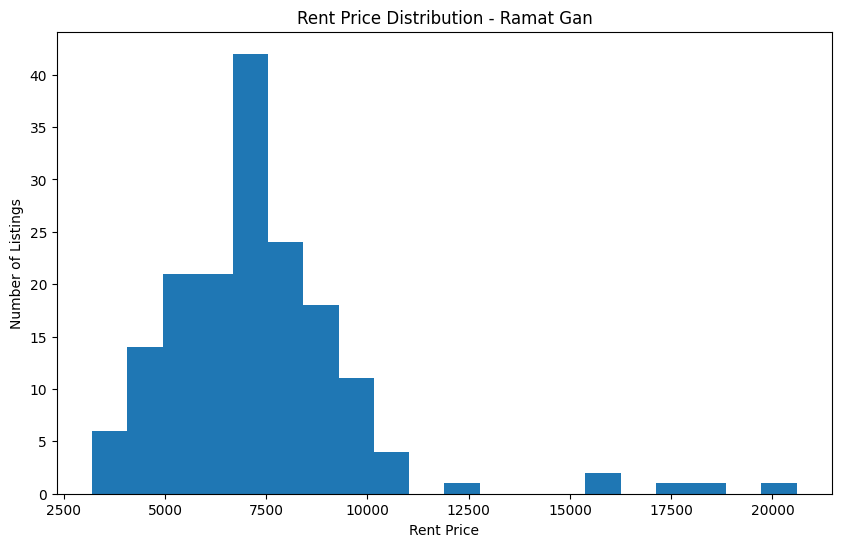

In [327]:
plt.figure(figsize=(10, 6))
plt.hist(rent_final["price"], bins=20)

plt.title(f"Rent Price Distribution - {CITY_NAME}")
plt.xlabel("Rent Price")
plt.ylabel("Number of Listings")

plt.show()

## 15. EDA - Average Rent by Neighborhood

This analysis shows which neighborhoods have the highest average rent.

In [328]:
avg_rent_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_rent_neighborhood.head(10)

,price
Neighborhood,
City Center C,8660.714286
Bursa District,8200.000000
HaRishonim,8049.900000
Hillel,7851.000000
Nahalat Ganim,7647.500000
Tel Yehuda,7563.636364
Yad Labanim,7016.666667
City Center B,6987.500000
HaBiluim,6711.111111


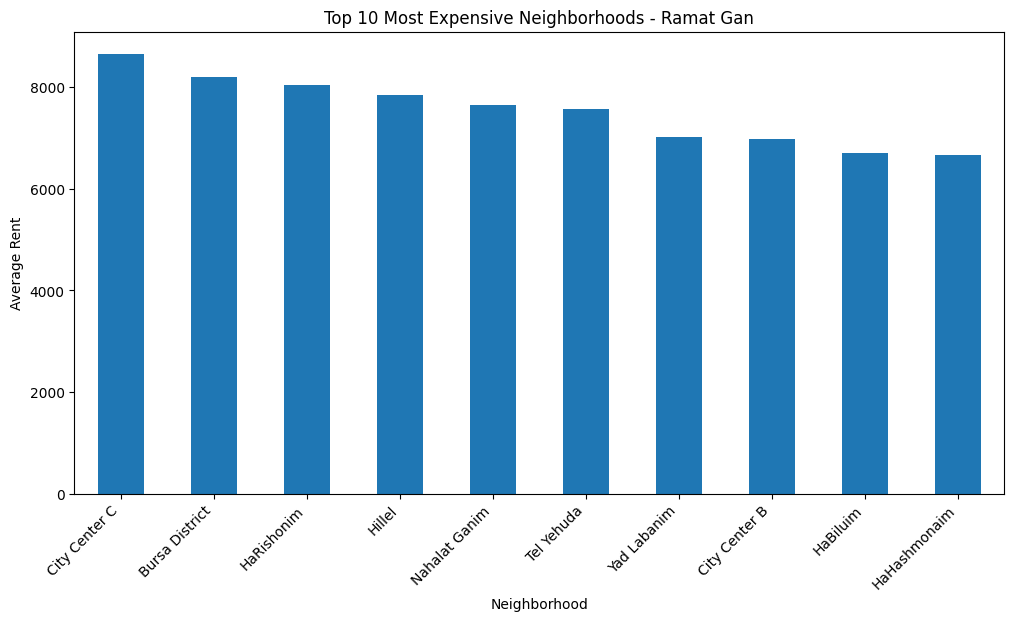

In [329]:
top_neighborhoods = avg_rent_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Most Expensive Neighborhoods - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 16. EDA - Cheapest Neighborhoods

This analysis shows the neighborhoods with the lowest average rent.

In [330]:
cheapest_neighborhoods = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=True)
)

cheapest_neighborhoods.head(10)

,price
Neighborhood,
Negba Complex,5900.000000
Neve Ram,6165.384615
HaGefen,6241.666667
Ramat Yitzhak,6541.666667
HaHashmonaim,6660.000000
HaBiluim,6711.111111
City Center B,6987.500000
Yad Labanim,7016.666667
Tel Yehuda,7563.636364


## 17. EDA - Rooms vs Rent Price

This analysis checks how rent price changes depending on the number of rooms.

In [331]:
avg_rent_by_rooms = (
    rent_final
    .groupby("rooms")["price"]
    .mean()
    .sort_values()
)

avg_rent_by_rooms

,price
rooms,
1.5,3200.000000
6.0,4500.000000
2.0,4976.875000
2.5,5754.545455
3.5,6376.923077
3.0,7052.303571
4.5,7366.666667
4.0,7711.363636
5.5,8500.000000


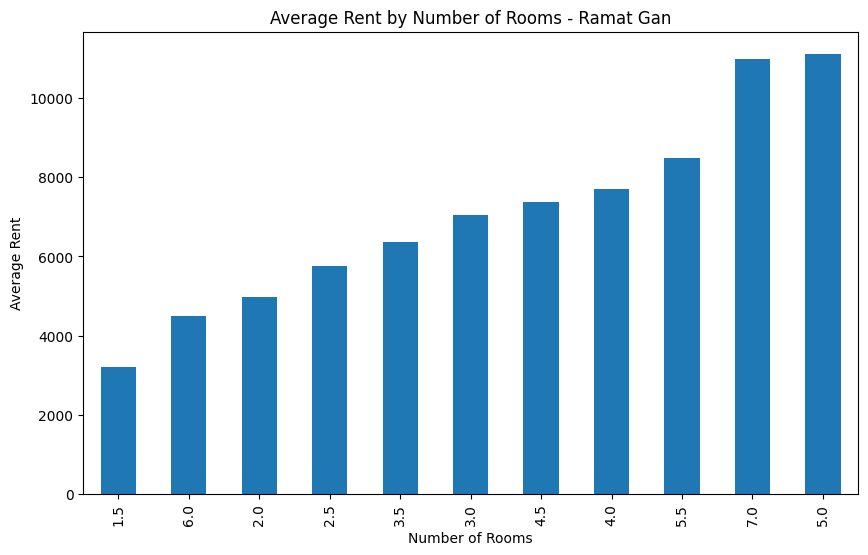

In [332]:
plt.figure(figsize=(10, 6))
avg_rent_by_rooms.plot(kind="bar")

plt.title(f"Average Rent by Number of Rooms - {CITY_NAME}")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Rent")

plt.show()

## 18. EDA - Price per Square Meter

Price per square meter is useful because it allows comparison between apartments of different sizes.

In [333]:
avg_sqm_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price_per_sqm"]
    .mean()
    .sort_values(ascending=False)
)

avg_sqm_neighborhood.head(10)

,price_per_sqm
Neighborhood,
Bursa District,99.995000
Nahalat Ganim,95.731250
Hillel,92.468333
Ramat Yitzhak,88.411667
City Center C,84.947143
Tel Yehuda,83.877273
HaRishonim,81.858000
Yad Labanim,81.096667
HaGefen,80.298333


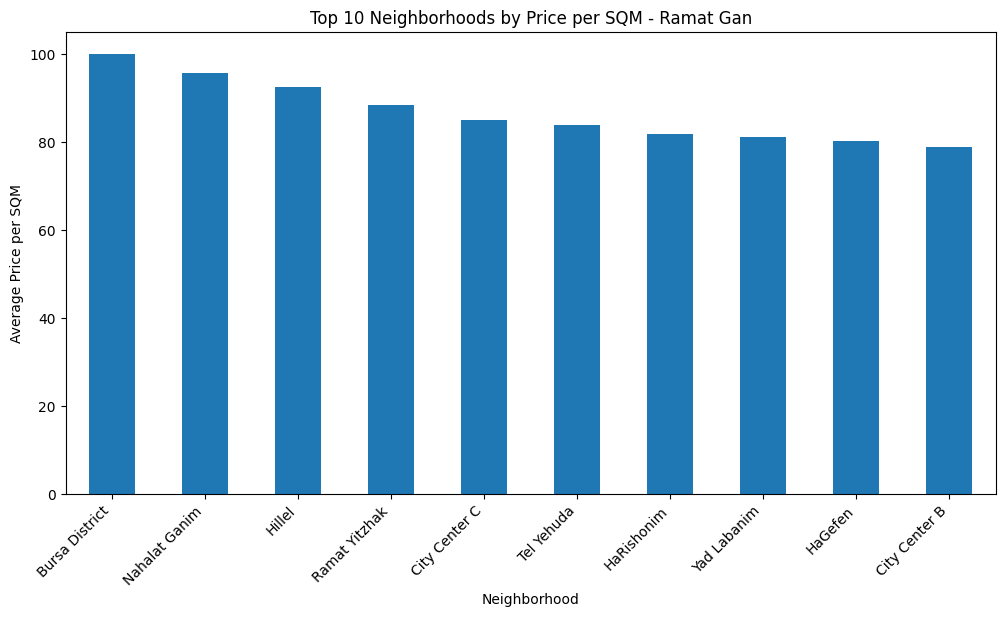

In [334]:
top_sqm_neighborhoods = avg_sqm_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_sqm_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Neighborhoods by Price per SQM - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price per SQM")

plt.xticks(rotation=45, ha="right")
plt.show()

## 19. Export Clean Dataset

Finally, I export the cleaned dataset as a CSV file.

This file will later be combined with other city datasets.

In [335]:
# Export final clean dataset
rent_final.to_csv(OUTPUT_FILE, index=False)

print(f"File exported successfully: {OUTPUT_FILE}")

File exported successfully: ramat_gan_rent_clean.csv


In [336]:
from google.colab import files

files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>